# EXLORATORY DATA ANALYSIS

To explore our data, first we need to import these libraries:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns 
import plotly.express as px # For interactive graphs

In [22]:
import warnings
warnings.filterwarnings('ignore')

Now, let's import the clean database using the `parquet` file to load the datatypes we changed previously.

In [2]:
studio_ghibli = pd.read_parquet("../data/Studio Ghibli - Clean.parquet")

studio_ghibli.head()

,Name,Year,Director,Screenplay,Budget,Revenue,Genre 1,Genre 2,Genre 3,Duration
0,When Marnie Was There,2014,Hiromasa Yonebayashi,Joan G. Robinson,1150000000,34949567,Animation,Drama,Thriller,0 days 01:43:00
1,The Tale of The Princess Kaguya,2013,Isao Takahata,Riko Sakaguchi,49300000,24366656,Animation,Drama,Fantasy,0 days 02:17:00
2,The Wind Rises,2013,Hayao Miyazaki,Tatsuo Hori,30000000,117932401,Drama,Animation,Romance,0 days 02:06:00
3,From Up on Poppy Hill,2011,Goro Miyazaki,Hayao Miyazaki,22000000,61037844,Animation,Drama,Romance,0 days 01:31:00
4,The Secret World of Arrietty,2010,Hiromasa Yonebayashi,Mary Norton,23000000,149480483,Fantasy,Animation,Family,0 days 01:34:00


And we can see, the datatypes were successfully loaded. 

In [3]:
studio_ghibli.dtypes

Name                      str
Year                    int16
Director               string
Screenplay             string
Budget                  int64
Revenue                 int64
Genre 1                string
Genre 2                string
Genre 3                string
Duration      timedelta64[us]
dtype: object

Now, let's create the color palette and load the font that we will use for the graphs. 

In [4]:
palette = ['#F4E3D3', '#EEBCB1', '#94C5CC', '#F4ADB3', '#ECD89D']

In [5]:
plot_font = font_manager.FontProperties(fname = "../assets/AutourOne-Regular.ttf")

---

## Quest 1: Runtime vs. Budget

As defined in my `README` file, for this first quest we are asking ourselves: _"Does the runtime of a Ghibli movie affect the budget?"_. This question leads us to think we need to compare the **Duration** vs. the **Budget**, and this means, we need to compare Numerical vs. Numerical data. For this type of analysis, the best option is to use a **Scatter Plot**.

We will use both `matplotlib` and `seaborn` to show the results of this analysis (to practice both plot libraries). 

In [6]:
# Extracting Budget and Duration from the database to compare them
x = studio_ghibli["Duration"].dt.seconds / 60 # This will convert the values we have to minutes. Easier to visualize
y = studio_ghibli["Budget"] / 1E6 # To see a better million format

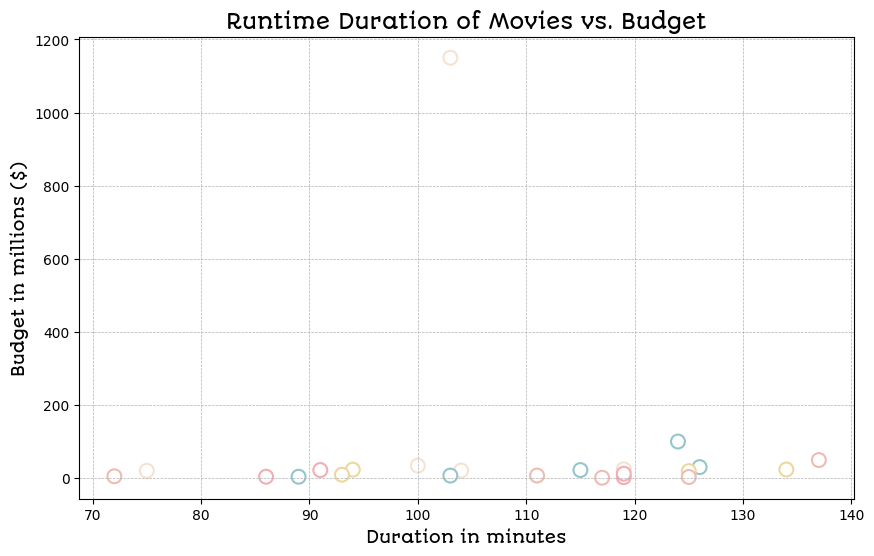

In [7]:
# Scatter Plot
plt.figure(figsize = (10,6)) # 10 x 6 inches plot

plt.scatter(x, y, 
            c = "w", edgecolor = palette, 
            s = 100, linewidths = 1.5)
plt.title("Runtime Duration of Movies vs. Budget", 
          fontproperties = plot_font, 
          fontsize = 15)
plt.xlabel("Duration in minutes", 
           fontproperties = plot_font, 
           fontsize = 12)
plt.ylabel("Budget in millions ($)", 
           fontproperties = plot_font, 
           fontsize = 12)

plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)
plt.show()

With this, we can notice there is an outlier in the `Budget` column, let's analyze it. 

In [8]:
studio_ghibli["Budget"].sort_values()

21       1000000
8        2500000
16       3000000
12       3700000
13       3700000
6        5000000
17       6900000
11       7000000
19       9200000
18      12000000
9       19000000
20      20000000
10      20500000
3       22000000
7       22000000
4       23000000
14      23500000
15      24000000
2       30000000
5       34000000
1       49300000
22     100000000
0     1150000000
Name: Budget, dtype: int64

We can see there are one extremely large value (in billions!), and another big one (index 22). Before continuing with this analysis, I will check to which movie these values belong and see if they are actually correct by looking them up in Google.

In [9]:
studio_ghibli["Name"].iloc[[0, 22]]

0     When Marnie Was There
22    The Boy and the Heron
Name: Name, dtype: str

From what I found, the movie "When Marnie Was There" had a budget of ¥1.15 billion, aproximatelly $10.5 million. The value that we have in our database is the yen value, not the dollar one.  

On the other hand, for the movie "The Boy and the Heron", the budget was estimated in $64 million, not in $100 million. 

This investigation showed us there are two wrong values within the database. If we change those values, there will be no wrong data anymore and we will be able to analyze it.

In [10]:
studio_ghibli.loc[studio_ghibli["Name"] == "When Marnie Was There", "Budget"] = 10500000
studio_ghibli.loc[studio_ghibli["Name"] == "The Boy and the Heron", "Budget"] = 64000000
studio_ghibli.head()

,Name,Year,Director,Screenplay,Budget,Revenue,Genre 1,Genre 2,Genre 3,Duration
0,When Marnie Was There,2014,Hiromasa Yonebayashi,Joan G. Robinson,10500000,34949567,Animation,Drama,Thriller,0 days 01:43:00
1,The Tale of The Princess Kaguya,2013,Isao Takahata,Riko Sakaguchi,49300000,24366656,Animation,Drama,Fantasy,0 days 02:17:00
2,The Wind Rises,2013,Hayao Miyazaki,Tatsuo Hori,30000000,117932401,Drama,Animation,Romance,0 days 02:06:00
3,From Up on Poppy Hill,2011,Goro Miyazaki,Hayao Miyazaki,22000000,61037844,Animation,Drama,Romance,0 days 01:31:00
4,The Secret World of Arrietty,2010,Hiromasa Yonebayashi,Mary Norton,23000000,149480483,Fantasy,Animation,Family,0 days 01:34:00


And plotting it again, we have that: 

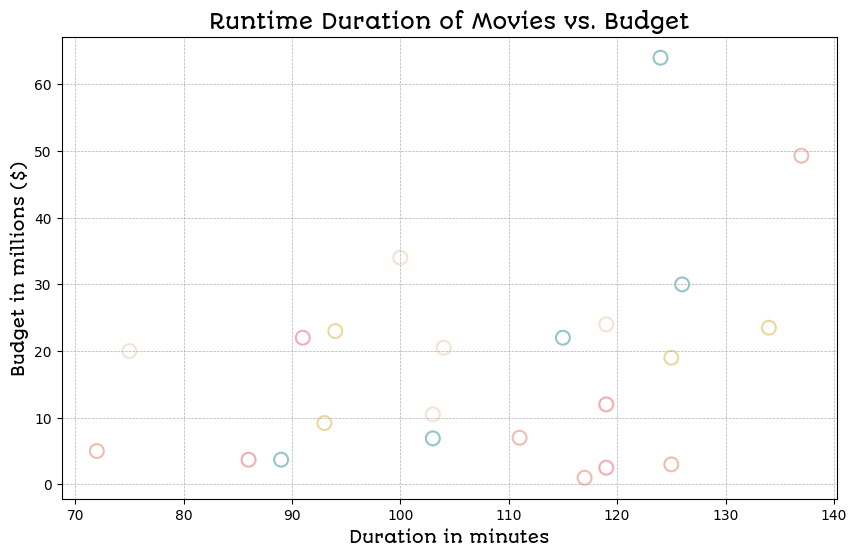

In [11]:
# Updating the values
x = studio_ghibli["Duration"].dt.seconds / 60
y = studio_ghibli["Budget"] / 1E6

# Scatter Plot with matplotlib
plt.figure(figsize = (10,6))

plt.scatter(x, y, 
            c = "w", edgecolor = palette, 
            s = 100, linewidths = 1.5)
plt.title("Runtime Duration of Movies vs. Budget", 
          fontproperties = plot_font, 
          fontsize = 15)
plt.xlabel("Duration in minutes", 
           fontproperties = plot_font, 
           fontsize = 12)
plt.ylabel("Budget in millions ($)", 
           fontproperties = plot_font, 
           fontsize = 12)

plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)
plt.show()

Now, let's plot this with `Seaborn`.

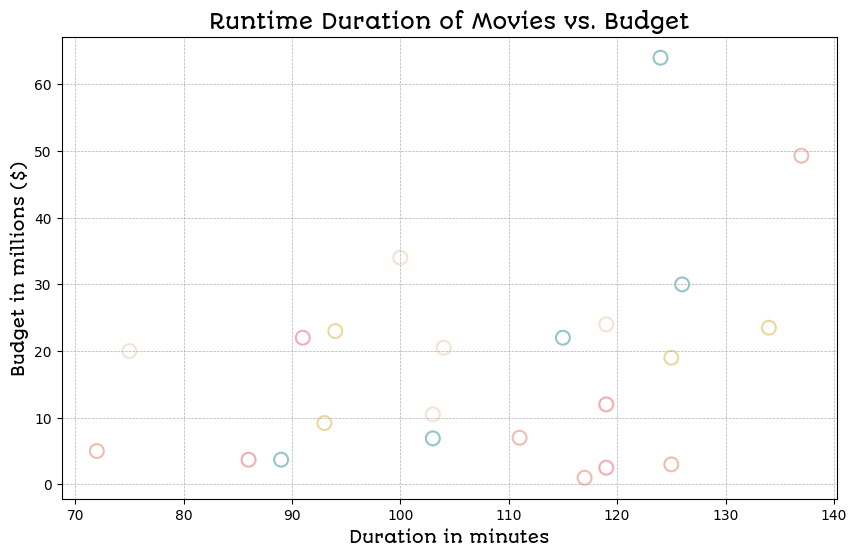

In [12]:
# Scatter Plot with Seaborn
plt.figure(figsize = (10,6))

sns.scatterplot(x = x, y = y,
                color = "white", edgecolor = palette,
                s = 100, linewidth = 1.5)

plt.title("Runtime Duration of Movies vs. Budget", 
          fontproperties = plot_font, 
          fontsize = 15)
plt.xlabel("Duration in minutes", 
           fontproperties = plot_font, 
           fontsize = 12)
plt.ylabel("Budget in millions ($)", 
           fontproperties = plot_font, 
           fontsize = 12)

plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)
plt.show()

With this, we can notice that there is a weak trend that says: "The bigger the runtime, the greater the budget". However, to validate this exploration, we will first look at the **Correlation Coefficient** to see how strong this trend is. 

In [13]:
correlation = x.corr(y)
print(f"The correlation score (Pearson's r) is: {correlation}")

The correlation score (Pearson's r) is: 0.3803013988558796


As we inferred, this $\rho_{X,Y} \approx 0.38$ is showing us that this trend is really weak, but we do have a positive correlation. Before we can conclude this analysis, we have one more tool that we can use: a **Regression Plot** with the help of `Seaborn`. This regression line will tell us if our hypothesis is correct or not.  

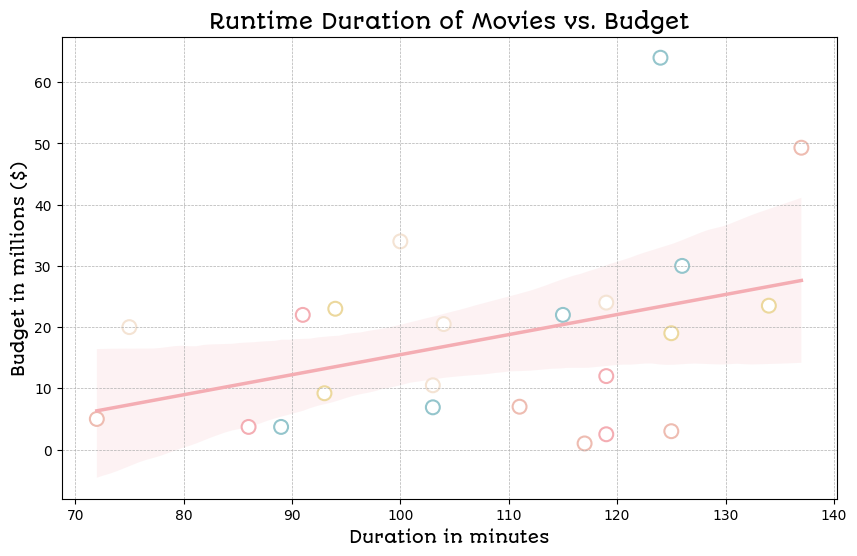

In [14]:
# Regression Plot with Seaborn
plt.figure(figsize = (10,6))

sns.regplot(x = x, y = y,
            scatter = False, color = palette[3], 
            line_kws = {"linewidth": 2.5})


sns.scatterplot(x = x, y = y,
                color = "white", edgecolor = palette,
                s = 100, linewidth = 1.5)

plt.title("Runtime Duration of Movies vs. Budget", 
          fontproperties = plot_font, 
          fontsize = 15)
plt.xlabel("Duration in minutes", 
           fontproperties = plot_font, 
           fontsize = 12)
plt.ylabel("Budget in millions ($)", 
           fontproperties = plot_font, 
           fontsize = 12)

plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)
plt.show()

With this Regression Line, we can assume this: The longer the movie, the greater the budget. And the graph is telling us that 
- The 95% Confidence Interval gets wide on the right-hand side, this is because there are a just a couple of Ghibli movies over 130 minutes and we are guessing here with almost no evidence, causing this statistical uncertainty. 

### The veredict
The weak, but positive correlation between runtime and budget and the regression line tilting up shows us that as a Studio Ghibli movie gets longer, the greater the budget will be. In the real world, Studio Ghibli movies are famous and loved for their hand-drawn animation. Every single extra minute in the movies requires extra hand-made frames, which leads to more labor, more studio time. Therefore, more budget.  

In conclusion, does the runtime of a Ghibli movie affect the budget? Yes, it does. 

---

## Quest 2: Revenue vs. Profit vs. ROI Percentage

For this quest, we want to see which director is the actual "Boss"—meaning, who is the most sucessful one. In order to get an answer, we need to use three values:
- **Revenue:** This is the money people paid for tickets. 
- **Profit:** Here, we are comparing what the movie earned while screening (the revenue) with the movie's cost (the budget). We will use the difference $\text{Revenue} - \text{Budget}$ to get this value.
- **ROI Percentage:** With this, we are measuring efficiency, where we compare the director's profit vs. the budget to see if the director made a profit or a loss.

Before moving to the analysis, let's add these last two values to our table:

In [15]:
studio_ghibli["Profit"] = studio_ghibli["Revenue"] - studio_ghibli["Budget"]
studio_ghibli["ROI Percentage"] = (studio_ghibli["Profit"] / studio_ghibli["Budget"]) * 100 
studio_ghibli.head()

,Name,Year,Director,Screenplay,Budget,Revenue,Genre 1,Genre 2,Genre 3,Duration,Profit,ROI Percentage
0,When Marnie Was There,2014,Hiromasa Yonebayashi,Joan G. Robinson,10500000,34949567,Animation,Drama,Thriller,0 days 01:43:00,24449567,232.853019
1,The Tale of The Princess Kaguya,2013,Isao Takahata,Riko Sakaguchi,49300000,24366656,Animation,Drama,Fantasy,0 days 02:17:00,-24933344,-50.574734
2,The Wind Rises,2013,Hayao Miyazaki,Tatsuo Hori,30000000,117932401,Drama,Animation,Romance,0 days 02:06:00,87932401,293.108003
3,From Up on Poppy Hill,2011,Goro Miyazaki,Hayao Miyazaki,22000000,61037844,Animation,Drama,Romance,0 days 01:31:00,39037844,177.444745
4,The Secret World of Arrietty,2010,Hiromasa Yonebayashi,Mary Norton,23000000,149480483,Fantasy,Animation,Family,0 days 01:34:00,126480483,549.915143


Now, because we want to do the analysis for each director, we need to do a Numerical vs. Categorical analysis. For this, we will use a barplot of the average ROI for each director.

In [16]:
director_roi = studio_ghibli.groupby("Director")["ROI Percentage"].mean().sort_values(ascending = True)
director_roi

Director
Tomomi Mochizuki         -98.000000
Hiroyuki Morita          170.081850
Goro Miyazaki            194.688518
Hiromasa Yonebayashi     391.384081
Yoshifumi Kondo          398.571429
Hayao Miyazaki           486.120726
Isao Takahata           7529.391152
Name: ROI Percentage, dtype: float64

We can see that Isao Takahata have a considerable big ROI percentage, let's analyze the revenue to see if there is no mistake on the dataset values.

In [17]:
studio_ghibli.loc[studio_ghibli["Director"] == "Isao Takahata", ["Name", "Revenue"]]

,Name,Revenue
1,The Tale of The Princess Kaguya,24366656
8,Only Yesterday,473110
10,My Neighbors the Yamadas,167000000
12,Grave of the Fireflies,516962
18,Pom Poko,4470000000


There is another billion value in this data for the movie "Pom Poko" and perhaps, "My Neighbors the Yamadas" can be a mistake too.

By looking them up in Google, the value for "Pom Poko" was saved in yens and the revenue for "My Neighbors the Yamadas" was also incorrect, so we need to update them:

In [18]:
studio_ghibli.loc[studio_ghibli["Name"] == "My Neighbors the Yamadas", ["Revenue"]] = 11900000
studio_ghibli.loc[studio_ghibli["Name"] == "Pom Poko", ["Revenue"]] = 26300000
studio_ghibli.loc[studio_ghibli["Director"] == "Isao Takahata", ["Name", "Revenue"]]

# Updating the Profit and ROI percentage
studio_ghibli["Profit"] = studio_ghibli["Revenue"] - studio_ghibli["Budget"]
studio_ghibli["ROI Percentage"] = (studio_ghibli["Profit"] / studio_ghibli["Budget"]) * 100 
director_roi = studio_ghibli.groupby("Director")["ROI Percentage"].mean().sort_values(ascending = True)

Now that these values are changed, we can do the box plot using both `Mathplotlib` and `Seaborn`.

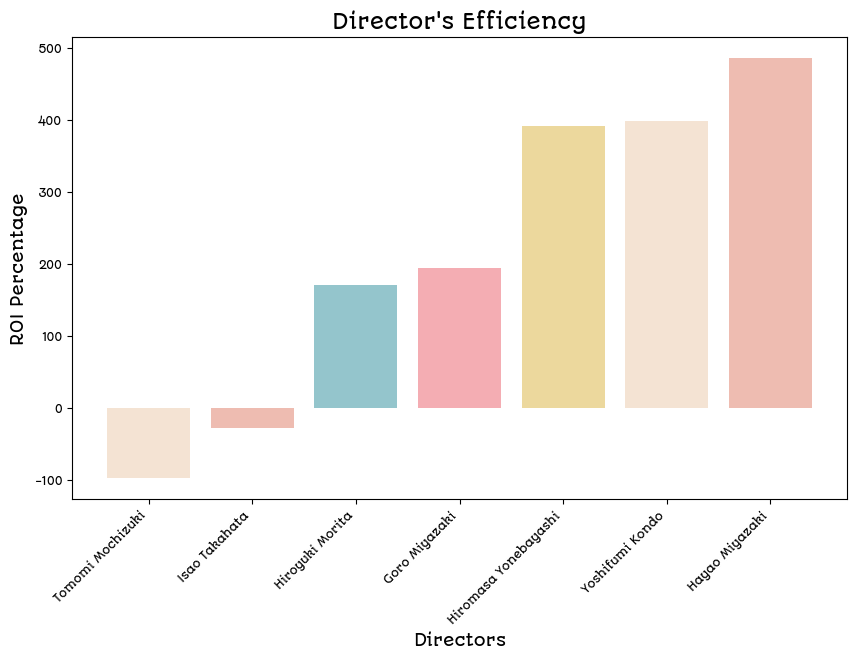

In [19]:
# Bar Plot for each director with mathplotlib
plt.figure(figsize = (10,6))

plt.bar(director_roi.index.to_list(), director_roi,
       color = palette)

plt.title("Director's Efficiency", 
          fontproperties = plot_font, 
          fontsize = 15)
plt.ylabel("ROI Percentage", 
           fontproperties = plot_font, 
           fontsize = 12)
plt.xlabel("Directors", 
           fontproperties = plot_font, 
           fontsize = 12)
plt.xticks(rotation = 45, ha = "right",
           fontproperties = plot_font, fontsize = 8)
plt.yticks(fontproperties = plot_font, fontsize = 8)

plt.show()

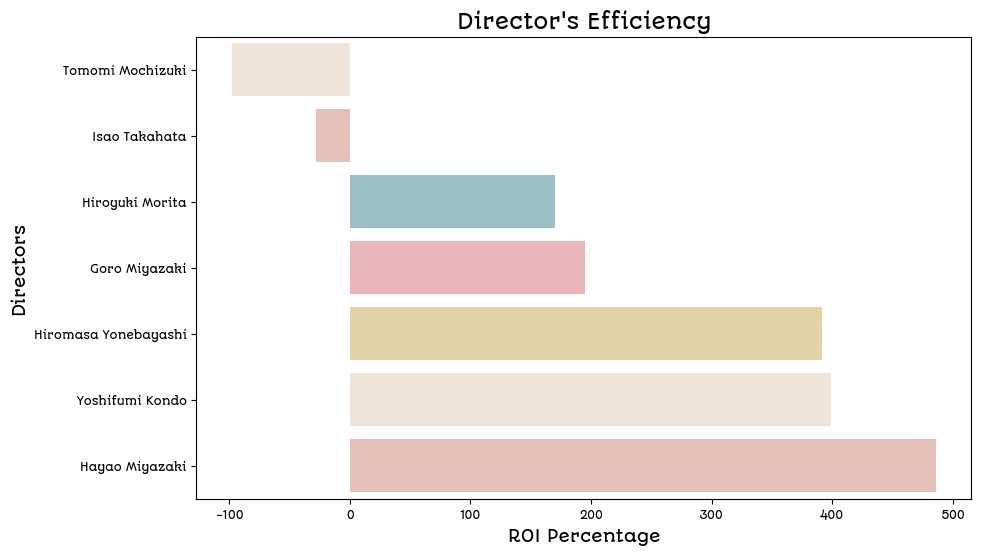

In [23]:
# Bar Plot for each director with Seaborn
plt.figure(figsize = (10,6))

sns.barplot(data = director_roi.reset_index(), x = "ROI Percentage", y = "Director", hue = "Director", palette = palette)

plt.title("Director's Efficiency", 
          fontproperties = plot_font, 
          fontsize = 15)
plt.xlabel("ROI Percentage", 
           fontproperties = plot_font, 
           fontsize = 12)
plt.ylabel("Directors", 
           fontproperties = plot_font, 
           fontsize = 12)
plt.yticks(fontproperties = plot_font, fontsize = 8)
plt.xticks(fontproperties = plot_font, fontsize = 8)

plt.show()

The answer for our **Quest 2: Which director is the "Boss"?** is the director with the highest ROI percentage: **Hayao Miyazaki**. Matching this result with what we know, Hayao Miyazaki is very beloved for the Studio Ghibli fans and he isthe director of very popular Ghibli movies, so it was expected for him to be the "boss". 

In [28]:
studio_ghibli.sort_values(by="Profit", ascending=False).head()

,Name,Year,Director,Screenplay,Budget,Revenue,Genre 1,Genre 2,Genre 3,Duration,Profit,ROI Percentage
9,Spirited Away,2001,Hayao Miyazaki,Hayao Miyazaki,19000000,274925095,Animation,Family,Fantasy,0 days 02:05:00,255925095,1346.974184
15,Howl's Moving Castle,2004,Hayao Miyazaki,Diana Wynne Jones,24000000,236049757,Fantasy,Animation,Adventure,0 days 01:59:00,212049757,883.540654
5,Ponyo,2008,Hayao Miyazaki,Hayao Miyazaki,34000000,202404009,Animation,Fantasy,Family,0 days 01:40:00,168404009,495.305909
14,Princess Mononoke,1997,Hayao Miyazaki,Hayao Miyazaki,23500000,169000000,Adventure,Fantasy,Animation,0 days 02:14:00,145500000,619.148936
4,The Secret World of Arrietty,2010,Hiromasa Yonebayashi,Mary Norton,23000000,149480483,Fantasy,Animation,Family,0 days 01:34:00,126480483,549.915143


---
Before finishing, as we changed the database in some quests because of the wrong data and the extra columns, let's save it for future use. 

In [21]:
#studio_ghibli.to_csv("../data/Studio Ghibli - Clean.csv")
#studio_ghibli.to_parquet("../data/Studio Ghibli - Clean.parquet")